# Model Development, Training, and Hyperparameter Optimization

## 🔗 Builds on (AIAT 111–125)

AIAT 126 is the *graduation* project: it **assembles** what you already built across the diploma, it does not re-teach it. Open what you need:

- **AIAT 114 U5 — grid search, the tuning loop this notebook runs on your data** → [`Course 04/unit5-model-selection/examples/01_grid_search.ipynb`](../../../Course%2004/unit5-model-selection/examples/01_grid_search.ipynb)
- **AIAT 111 U3 — gradient descent and loss functions: whatever architecture you picked, it still learns the same way** → [`Course 01/unit3-ml-basics/examples/04_gradient_descent_loss_functions.ipynb`](../../../Course%2001/unit3-ml-basics/examples/04_gradient_descent_loss_functions.ipynb)
- **AIAT 114 U2 — cross-validation and learning curves** → [`Course 04/unit2-regression-model-evaluation/examples/01_cross_validation.ipynb`](../../../Course%2004/unit2-regression-model-evaluation/examples/01_cross_validation.ipynb)
- **AIAT 113 U3 — optimizers and loss functions, when tuning stops helping** → [`Course 03/unit3-optimization/examples/01_optimizers_comparison.ipynb`](../../../Course%2003/unit3-optimization/examples/01_optimizers_comparison.ipynb)
- **AIAT 122 U1 — only if your model is a neural network** → [`Course 08/unit1-deep-learning-basics/examples/06_optimization_techniques.ipynb`](../../../Course%2008/unit1-deep-learning-basics/examples/06_optimization_techniques.ipynb)
- **AIAT 125 U5 — experiment tracking, so your tuning runs are reproducible** → [`Course 11/unit5-pipelines-monitoring/examples/05_experiment_tracking_mlflow_wandb.ipynb`](../../../Course%2011/unit5-pipelines-monitoring/examples/05_experiment_tracking_mlflow_wandb.ipynb)

Record every artifact you reuse in **section 6, the Prior Work Inventory**, of [`TEMPLATES/project_proposal_template.md`](../../TEMPLATES/project_proposal_template.md). It is scored at gate 1 (criterion 1.7) and re-checked at the Unit 2 design review — it is this course's **CLO2** evidence, and the official AIAT 126 description requires it.

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement model architecture and training pipeline
- Train models with different hyperparameter configurations
- Perform hyperparameter optimization using grid search and automated tools
- Evaluate model performance using appropriate metrics
- Read tuning results against the baseline honestly and decide when refinement is worth it

## 🔗 Where this leads

**Used later in:** Course 12 — Unit 4, which evaluates the tuned model and decides whether the tuning was worth it.

---

This notebook covers practical activities from **Course 12, Unit 3**:
- Implementing model architecture and training pipeline
- Training models with different hyperparameter configurations
- Performing hyperparameter optimization using grid search or automated tools
- Evaluating model performance using appropriate metrics
- Analyzing model outputs and identifying areas for improvement
- Interpreting tuning results against the baseline honestly
- Documenting training procedures and results

---

## Introduction

**Model Development** involves selecting appropriate algorithms, designing architectures, training models, and optimizing hyperparameters. Tuning is a disciplined search — as this notebook's own results will show, it is *not* a guarantee of beating a strong default baseline, and reading its results honestly is part of the craft.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- **Your own project dataset**, if you have one: put it at `data/my_project_data.csv` next to this
  notebook (same convention as notebook 01 of this unit) and this pipeline will pick it up
- Otherwise a real named fallback — the 1912 Titanic passenger manifest at
  `../../../Course 04/datasets/raw/titanic.csv` — so the tuning runs against a genuine signal ceiling

**Outputs:** What you'll see when you run the cells

- Baseline metrics, a grid search and a random search over Random Forest hyperparameters,
  and a computed verdict on whether the tuning was actually worth it.

---

---

## The $1,000,000 of tuning that was never deployed

In October 2006 Netflix offered **$1 million** to anyone who could improve its rating predictions by 10%. Three years and thousands of teams later, "BellKor's Pragmatic Chaos" cleared the bar and took the cheque. The winning entry was an ensemble of **more than 800 models** blended together.

Netflix never put it into production. Its engineering blog gave the reason in 2012, in one sentence: *"we evaluated some of the new methods offline but the additional accuracy gains that we measured did not seem to justify the engineering effort needed to bring them into a production environment."* Two components of the solution — an SVD and a restricted Boltzmann machine — went into the product. The other several hundred did not. And by the time the prize was awarded Netflix had become a streaming company, so the thing the competition had spent three years optimising — predicting a five-star rating for a DVD arriving in three days — was no longer the thing the business needed.

Every element of that story is available to you in this notebook, at a scale of minutes instead of years: a search that optimises a number, a number that improves, and a separate question the search itself can never answer — **was it worth it?**

### What goes wrong without this

The failure this lesson prevents is not "my model is under-tuned". It is **spending the last three weeks of a capstone on hyperparameters** and arriving at the defence with a model 0.3 points better than the default, no baseline comparison, no failure analysis and no working demo. Tuning is the most seductive activity in a machine-learning project because it always produces a number and never produces a decision.

It also fails quietly in a specific way: you tune, you check the validation set, you tune again, you check again — and after enough rounds your validation score has stopped measuring the model and started measuring how many times you looked.

### The same reasoning, two other fields

- **Neural recommenders — Ferrari Dacrema, Cremonesi & Jannach (RecSys 2019).** The authors took **18** neural recommendation methods published at top conferences. Only **7** could be reproduced at all, and **6 of those 7** were beaten by simple, well-tuned baselines such as nearest-neighbour methods; the seventh did not consistently beat a well-tuned linear ranking method. Much of the published "progress" was a tuning-budget gap between the new method and the baseline it was measured against.
- **Neural language models — Melis, Dyer & Blunsom (ICLR 2018).** Given a large automatic hyperparameter-search budget, a *plain* LSTM outperformed the newer architectures published after it, setting new state-of-the-art results on Penn Treebank and WikiText-2. Again: what looked like architectural progress was partly a difference in how hard each model had been tuned.

Read those next to the cells you are about to run, where a default random forest and a tuned one finish within noise of each other. Two research literatures found the same thing at scale: **an untuned baseline is not a fair baseline — and a tuned baseline is often all you needed.**

In [1]:
# Import everything used below: data generation, model, metrics, and the three
# search/validation tools (train_test_split, GridSearchCV/RandomizedSearchCV, cross_val_score).
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print("✅ Libraries imported!")


✅ Libraries imported!


In [2]:
# Load the project dataset: YOUR file if it exists, a real named fallback otherwise.
# WHY a real dataset matters here: hyperparameter tuning is only interesting when there is
# a genuine ceiling to bump into. On invented data you can usually reach any score you like
# by making the problem easier, which teaches you nothing about tuning.
PROJECT_DATA = Path("data/my_project_data.csv")      # <- your own dataset goes here
FALLBACK_DATA = Path("../../../Course 04/datasets/raw/titanic.csv")

if PROJECT_DATA.exists():
    raw_data = pd.read_csv(PROJECT_DATA)
    data_source = f"YOUR project dataset ({PROJECT_DATA})"
    # EDIT: name your own target column and drop any identifier columns.
    TARGET = "target"
    features = raw_data.drop(columns=[TARGET])
    X = pd.get_dummies(features, drop_first=True).fillna(0).to_numpy(dtype=float)
    y = raw_data[TARGET].to_numpy()
else:
    raw_data = pd.read_csv(FALLBACK_DATA)
    data_source = f"fallback: real Titanic passenger manifest ({FALLBACK_DATA.name}, 1912)"
    print(f"ℹ️  No file at {PROJECT_DATA} — using the real fallback dataset instead.\n")

    # Real gaps need real decisions before any model can be fitted.
    clean = raw_data.copy()
    clean["Age"] = clean["Age"].fillna(clean["Age"].median())
    clean["Embarked"] = clean["Embarked"].fillna(clean["Embarked"].mode()[0])
    features = pd.DataFrame({
        "pclass": clean["Pclass"],
        "is_female": (clean["Sex"] == "female").astype(int),
        "age": clean["Age"],
        "sibsp": clean["SibSp"],
        "parch": clean["Parch"],
        "fare": clean["Fare"],
        "family_size": clean["SibSp"] + clean["Parch"] + 1,
        "embarked_C": (clean["Embarked"] == "C").astype(int),
        "embarked_Q": (clean["Embarked"] == "Q").astype(int),
    })
    TARGET = "Survived"
    X = features.to_numpy(dtype=float)
    y = clean[TARGET].to_numpy()

# Hold out 20% as a validation set; stratify keeps the class balance in both parts
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Source: {data_source}")
print(f"Features ({X.shape[1]}): {list(features.columns)}")
print(f"Training set: {X_train.shape}, Validation set: {X_val.shape}")
print(f"Class balance overall: {np.bincount(y).tolist()}")
print(f"Majority-class baseline on the validation set: {max(np.bincount(y_val)) / len(y_val):.4f}")

ℹ️  No file at data/my_project_data.csv — using the real fallback dataset instead.

Source: fallback: real Titanic passenger manifest (titanic.csv, 1912)
Features (9): ['pclass', 'is_female', 'age', 'sibsp', 'parch', 'fare', 'family_size', 'embarked_C', 'embarked_Q']
Training set: (712, 9), Validation set: (179, 9)
Class balance overall: [549, 342]
Majority-class baseline on the validation set: 0.6145


## Part 1: Baseline Model Training

Train a baseline model to establish performance benchmarks.


In [3]:
# Baseline first: train a random forest with DEFAULT hyperparameters — every
# tuning result later is judged against these numbers, so without a baseline
# you cannot tell whether tuning helped at all.
# Fit the out-of-the-box model on the training set
baseline_model = RandomForestClassifier(random_state=42)
baseline_model.fit(X_train, y_train)

# Score the baseline on the held-out validation set with the four headline metrics
y_val_pred = baseline_model.predict(X_val)
baseline_accuracy = accuracy_score(y_val, y_val_pred)
baseline_precision = precision_score(y_val, y_val_pred)
baseline_recall = recall_score(y_val, y_val_pred)
baseline_f1 = f1_score(y_val, y_val_pred)

print("=" * 60)
print("Baseline Model Performance")
print("=" * 60)
print(f"Accuracy:  {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall:    {baseline_recall:.4f}")
print(f"F1-Score:  {baseline_f1:.4f}")
print(f"(Majority-class baseline accuracy: {max(np.bincount(y_val)) / len(y_val):.4f})")

# Per-class precision/recall breakdown, kept for the project record
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))


Baseline Model Performance
Accuracy:  0.8045
Precision: 0.7656
Recall:    0.7101
F1-Score:  0.7368
(Majority-class baseline accuracy: 0.6145)

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       110
           1       0.77      0.71      0.74        69

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



## Part 2: Hyperparameter Optimization - Grid Search


In [4]:
# Grid search: exhaustively try every combination in a small parameter grid,
# scored by cross-validated F1 on the TRAINING folds (the validation set stays out).
# Define hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Grid Search
print("=" * 60)
print("Grid Search Hyperparameter Optimization")
print("=" * 60)
print("Searching over parameter combinations...")
print(f"Total combinations: {np.prod([len(v) for v in param_grid.values()])}")

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42), param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Evaluate best model
best_model = grid_search.best_estimator_
y_val_pred_best = best_model.predict(X_val)
best_accuracy = accuracy_score(y_val, y_val_pred_best)

print(f"\nValidation Accuracy with best params: {best_accuracy:.4f}")
# Signed change vs the baseline — watch the sign, it can be negative!
print(f"Change vs baseline accuracy: {best_accuracy - baseline_accuracy:+.4f}")


Grid Search Hyperparameter Optimization
Searching over parameter combinations...
Total combinations: 108
Fitting 5 folds for each of 108 candidates, totalling 540 fits



Best parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50}
Best cross-validation score: 0.7629

Validation Accuracy with best params: 0.7933
Change vs baseline accuracy: -0.0112


### Reading the result honestly: tuning did not beat the baseline here

Look at the printed numbers above: the tuned model's validation accuracy came
out *lower* than the baseline's (0.7933 vs 0.8045). That is a real and common
outcome — not a bug. Three things explain it:

1. **The search optimized a different criterion.** Grid search picked the
   parameters with the best *cross-validated F1 on the training folds* — it
   never saw the validation set. Judged by its own criterion, the search did
   its job (the next cell verifies this).
2. **The validation set is small.** With 179 passengers, one flipped prediction
   moves accuracy by 0.56%, so a gap of about one point is two predictions wide.
3. **Real data has a ceiling.** Survival on the Titanic was never a clean
   function of class, sex, age and fare, so no hyperparameter setting was going
   to push this much past 0.80. When the defaults are already near the ceiling,
   tuning has almost nothing left to win.

The professional response — the one to practice for your capstone — is to
report the result as it is, check the criterion the search actually optimized,
and resist re-tuning until the validation set says what you want: that is how
data leakage starts.

In [5]:
# Verify the search on ITS OWN criterion: compare cross-validated F1 of the
# default baseline vs the tuned model — the metric grid search optimized.
baseline_cv_f1 = cross_val_score(
    RandomForestClassifier(random_state=42), X_train, y_train, cv=5, scoring='f1'
).mean()

print('=' * 60)
print("Baseline vs Tuned — on the search's own criterion (CV F1)")
print('=' * 60)
print(f'Baseline (default params) CV F1: {baseline_cv_f1:.4f}')
print(f'Tuned (best params) CV F1:       {grid_search.best_score_:.4f}')

# Compute the verdict from the numbers instead of asserting it in prose
cv_delta = grid_search.best_score_ - baseline_cv_f1
val_delta = best_accuracy - baseline_accuracy
print(f'\nCV F1 change from tuning:   {cv_delta:+.4f}')
print(f'Validation accuracy change: {val_delta:+.4f}')

# Branch on what the numbers actually say, so the conclusion is computed, not asserted
if cv_delta >= 0 and val_delta < 0:
    print('\nInterpretation: tuning improved (or matched) the cross-validated score')
    print(f'it optimized, but did NOT improve accuracy on the {len(y_val)}-sample validation')
    print('set. With defaults this strong, honest reporting beats chasing noise.')
elif cv_delta >= 0:
    print('\nInterpretation: tuning improved both the CV score and validation accuracy.')
else:
    print('\nInterpretation: tuning failed to improve even its own CV criterion —')
    print('widen or rethink the search space before drawing conclusions.')

Baseline vs Tuned — on the search's own criterion (CV F1)
Baseline (default params) CV F1: 0.7347
Tuned (best params) CV F1:       0.7629

CV F1 change from tuning:   +0.0282
Validation accuracy change: -0.0112

Interpretation: tuning improved (or matched) the cross-validated score
it optimized, but did NOT improve accuracy on the 179-sample validation
set. With defaults this strong, honest reporting beats chasing noise.


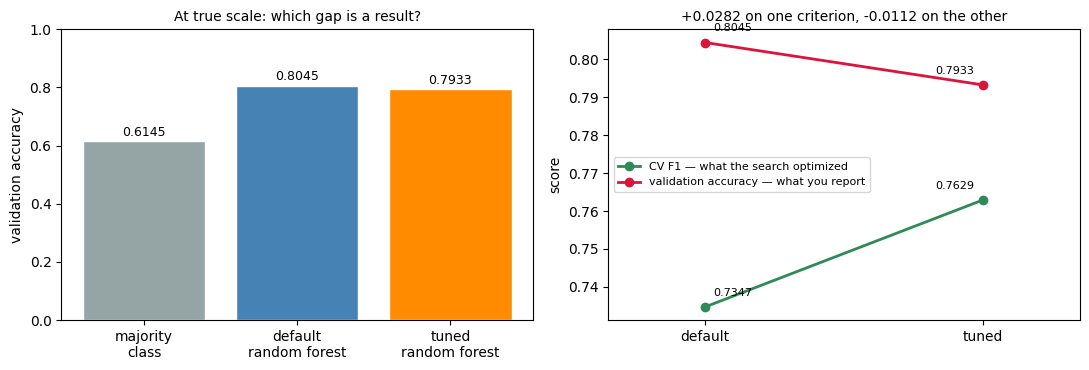

Left panel  — majority class 0.6145 -> default forest 0.8045 is a gap of +0.1899;
              default forest -> tuned forest is -0.0112, about 17x smaller.
Right panel — the green line rises and the red line falls. Same search, same run, opposite verdicts.


In [6]:
# The disagreement above, drawn. Three numbers were printed; the reason they are
# confusing is that they live on two different scales, so the eye never gets to
# compare them. Two panels fix that.
# WHY the left panel uses a full 0-to-1 axis: a bar chart zoomed onto a 0.01
# difference makes noise look like a result. That trick is how tuning sections
# get written. Here the axis is honest, and what it shows is the point.
majority_baseline = max(np.bincount(y_val)) / len(y_val)

fig, (ax_scale, ax_slope) = plt.subplots(1, 2, figsize=(11, 3.8))

# --- left: every accuracy number in the notebook, at true scale ---
names = ["majority\nclass", "default\nrandom forest", "tuned\nrandom forest"]
vals = [majority_baseline, baseline_accuracy, best_accuracy]
bars = ax_scale.bar(names, vals, color=["#95a5a6", "steelblue", "darkorange"],
                    edgecolor="white")
for b, v in zip(bars, vals):
    ax_scale.text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.4f}",
                  ha="center", fontsize=9)
ax_scale.set_ylim(0, 1.0)
ax_scale.set_ylabel("validation accuracy")
ax_scale.set_title("At true scale: which gap is a result?", fontsize=10)

# --- right: the two criteria as slopes, so their DIRECTIONS can be compared ---
# WHAT: each line joins the default model to the tuned model on one criterion.
# WHY a slope and not bars: the finding is the sign of each change, and a slope
# shows sign as direction, which needs no axis-reading at all.
ax_slope.plot([0, 1], [baseline_cv_f1, grid_search.best_score_],
              marker="o", color="seagreen", lw=2,
              label="CV F1 — what the search optimized")
ax_slope.plot([0, 1], [baseline_accuracy, best_accuracy],
              marker="o", color="crimson", lw=2,
              label="validation accuracy — what you report")
for x, y in ((0, baseline_cv_f1), (1, grid_search.best_score_),
             (0, baseline_accuracy), (1, best_accuracy)):
    ax_slope.annotate(f"{y:.4f}", (x, y), textcoords="offset points",
                      xytext=(6 if x == 0 else -6, 8),
                      ha="left" if x == 0 else "right", fontsize=8)
ax_slope.set_xticks([0, 1])
ax_slope.set_xticklabels(["default", "tuned"])
ax_slope.set_xlim(-0.35, 1.35)
ax_slope.set_ylabel("score")
ax_slope.set_title(f"{cv_delta:+.4f} on one criterion, {val_delta:+.4f} on the other",
                   fontsize=10)
ax_slope.legend(fontsize=8, loc="center left")

plt.tight_layout()
plt.show()

print(f"Left panel  — majority class {majority_baseline:.4f} -> default forest "
      f"{baseline_accuracy:.4f} is a gap of {baseline_accuracy - majority_baseline:+.4f};")
print(f"              default forest -> tuned forest is {val_delta:+.4f}, about "
      f"{abs((baseline_accuracy - majority_baseline) / val_delta):.0f}x smaller.")
print("Right panel — the green line rises and the red line falls. Same search, "
      "same run, opposite verdicts.")

### Reading the two panels

**Left panel — the gap that mattered has already happened.** Three bars, one honest
axis from 0 to 1. The step from the majority-class rule (0.6145) to an untuned random
forest (0.8045) is **+0.1899** and you can see it across the room. The step from the
untuned forest to the tuned one is **−0.0112**, and at this scale the two bars look
identical, because they nearly are: the whole yield of 540 model fits is **1.1% of
this axis**, and you have to be told it is there to find it. The cell printed the
ratio — the gap the project actually won is about **17 times** the gap tuning moved.
**Almost no tuning figure is drawn on an axis like this one**, and that is the habit
to notice: zooming the y-axis onto the last two decimal places is what makes a 0.01
difference look like a discovery.

**Right panel — the same search, two criteria, opposite directions.** The green line
goes *up*: cross-validated F1, the thing grid search was actually told to maximise,
improved from 0.7347 to 0.7629. The red line goes *down*: accuracy on the 179 held-out
passengers fell from 0.8045 to 0.7933. Neither line is wrong and neither is a bug. The
search never saw the validation set, so it optimised what it could see, and what it
could see is not what you report.

**Why this figure is the one to remember:** when the two lines disagree, you have to
choose which one to publish *before* you look — that decision belongs in the proposal,
not in the results section. A student who picks the green line after seeing both has
not measured a model; they have measured their own preference, and an examiner who asks
for the other number will find it in thirty seconds.

## Part 3: Hyperparameter Optimization - Random Search

Random search is more efficient for large parameter spaces.


In [7]:
# Random search: instead of trying EVERY combination like grid search, sample
# 20 random ones — far cheaper in large spaces, and usually nearly as good
# because only a few hyperparameters really matter (Bergstra & Bengio, 2012).
# A slightly wider space than the grid — random search can afford it
param_distributions = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6]
}

print("=" * 60)
print("Random Search Hyperparameter Optimization")
print("=" * 60)
print("Searching random parameter combinations (more efficient for large spaces)...")

# Same 5-fold CV and F1 criterion as grid search, but only 20 sampled configs
random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42), param_distributions,
    n_iter=20,  # Try 20 random combinations
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train, y_train)

print(f"\nBest parameters: {random_search.best_params_}")
print(f"Best cross-validation score: {random_search.best_score_:.4f}")

# Compare with grid search on the SAME criterion: cross-validated F1
print(f"\nGrid Search best score: {grid_search.best_score_:.4f}")
print(f"Random Search best score: {random_search.best_score_:.4f}")
print(f"Difference: {abs(grid_search.best_score_ - random_search.best_score_):.4f}")


Random Search Hyperparameter Optimization
Searching random parameter combinations (more efficient for large spaces)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits



Best parameters: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 20}
Best cross-validation score: 0.7555

Grid Search best score: 0.7629
Random Search best score: 0.7555
Difference: 0.0074


### What the two searches cost, and what they bought

Put the printed numbers side by side:

| Search | Fits performed | Best CV F1 |
|---|---|---|
| Grid — exhaustive | 108 combinations × 5 folds = **540 fits** | **0.7629** |
| Random — 20 samples of a *wider* space | 20 × 5 folds = **100 fits** | **0.7555** |

Random search used **under a fifth of the compute** and finished **0.0074** behind. A gap that size between two cross-validated estimates on 712 training rows is not a meaningful difference — change the seed and it could reverse. This is exactly what Bergstra and Bengio (2012) reported: in most spaces only a couple of hyperparameters matter much, so sampling finds the good region about as fast as enumerating it, while enumeration's cost multiplies with every parameter you add. **Add one more four-value parameter to the grid and it becomes 432 combinations, 2,160 fits; random search still costs 100.**

And note what the exhaustive search bought against the *baseline*: **+0.0282** CV F1 for 540 fits, and **−0.0112** accuracy on the validation set. Both numbers belong in your report. A tuning section that reports only the improvement it likes is precisely the habit gate 4 exists to catch.

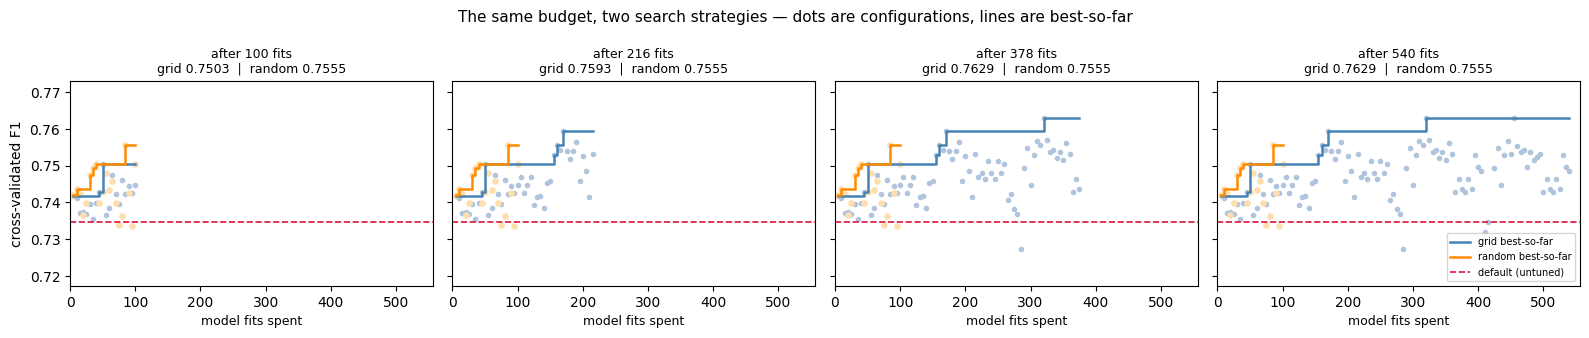

Step table — what each search had bought at each budget
 fits spent  grid cfgs  grid best  rand cfgs  rand best      gap
        100         20     0.7503         20     0.7555  -0.0052
        216         43     0.7593         20     0.7555   0.0038
        378         75     0.7629         20     0.7555   0.0074
        540        108     0.7629         20     0.7555   0.0074

Random search finished at 100 fits; grid search spent 540 to end +0.0074 ahead of it.
All 108 grid configurations scored between 0.7274 and 0.7629 — a spread of 0.0355.
The default model sits at 0.7347, inside that band: 104 of 108 configurations beat it.


In [8]:
# STEP STORYBOARD — the two searches, replayed frame by frame against one budget.
# WHAT: four snapshots of the same x-axis (model fits spent). In each frame, every
# configuration scored so far is a dot, and the thick line is the best score found
# so far. Grid search in blue, random search in orange.
# WHY a storyboard: "random search is cheaper" is a claim about a PROCESS, and a
# process needs more than one photograph. Watch the orange line stop while the
# blue one keeps spending.
# COST: zero new fits — both searches already stored every score in cv_results_.
FOLDS = 5
grid_scores = np.asarray(grid_search.cv_results_["mean_test_score"], dtype=float)
rand_scores = np.asarray(random_search.cv_results_["mean_test_score"], dtype=float)
grid_fits = np.arange(1, len(grid_scores) + 1) * FOLDS
rand_fits = np.arange(1, len(rand_scores) + 1) * FOLDS
grid_best = np.maximum.accumulate(grid_scores)     # best-so-far, frame by frame
rand_best = np.maximum.accumulate(rand_scores)

total_fits = int(grid_fits[-1])
budgets = sorted({int(rand_fits[-1]), int(total_fits * 0.4),
                  int(total_fits * 0.7), total_fits})

lo = min(grid_scores.min(), rand_scores.min(), baseline_cv_f1) - 0.01
hi = max(grid_scores.max(), rand_scores.max(), baseline_cv_f1) + 0.01

fig, axes = plt.subplots(1, len(budgets), figsize=(16, 3.4), sharey=True)
for ax, budget in zip(axes, budgets):
    gm, rm = grid_fits <= budget, rand_fits <= budget
    # the default model's CV F1: the line any search has to beat to be worth running
    ax.axhline(baseline_cv_f1, color="crimson", ls="--", lw=1.2)
    ax.scatter(grid_fits[gm], grid_scores[gm], s=9, color="lightsteelblue")
    ax.step(grid_fits[gm], grid_best[gm], where="post", color="steelblue", lw=1.8)
    if rm.any():
        ax.scatter(rand_fits[rm], rand_scores[rm], s=14, color="navajowhite")
        ax.step(rand_fits[rm], rand_best[rm], where="post", color="darkorange", lw=1.8)
    g_now = grid_best[gm][-1] if gm.any() else float("nan")
    r_now = rand_best[rm][-1] if rm.any() else float("nan")
    ax.set_title(f"after {budget} fits\ngrid {g_now:.4f}  |  random {r_now:.4f}",
                 fontsize=9)
    ax.set_xlim(0, total_fits * 1.03)
    ax.set_ylim(lo, hi)
    ax.set_xlabel("model fits spent", fontsize=9)
axes[0].set_ylabel("cross-validated F1")
axes[-1].plot([], [], color="steelblue", lw=1.8, label="grid best-so-far")
axes[-1].plot([], [], color="darkorange", lw=1.8, label="random best-so-far")
axes[-1].plot([], [], color="crimson", ls="--", lw=1.2, label="default (untuned)")
axes[-1].legend(fontsize=7, loc="lower right")
fig.suptitle("The same budget, two search strategies — dots are configurations, "
             "lines are best-so-far", fontsize=11)
plt.tight_layout()
plt.show()

# The frames as a table, so the picture can be checked rather than trusted.
print("=" * 84)
print("Step table — what each search had bought at each budget")
print("=" * 84)
print(f"{'fits spent':>11}{'grid cfgs':>11}{'grid best':>11}"
      f"{'rand cfgs':>11}{'rand best':>11}{'gap':>9}")
for budget in budgets:
    gm, rm = grid_fits <= budget, rand_fits <= budget
    g_now = grid_best[gm][-1] if gm.any() else float("nan")
    r_now = rand_best[rm][-1] if rm.any() else float("nan")
    print(f"{budget:>11}{int(gm.sum()):>11}{g_now:>11.4f}"
          f"{int(rm.sum()):>11}{r_now:>11.4f}{g_now - r_now:>9.4f}")

print(f"\nRandom search finished at {int(rand_fits[-1])} fits; grid search spent "
      f"{total_fits} to end {grid_best[-1] - rand_best[-1]:+.4f} ahead of it.")
print(f"All {len(grid_scores)} grid configurations scored between "
      f"{grid_scores.min():.4f} and {grid_scores.max():.4f} — a spread of "
      f"{grid_scores.max() - grid_scores.min():.4f}.")
print(f"The default model sits at {baseline_cv_f1:.4f}, inside that band: "
      f"{int((grid_scores > baseline_cv_f1).sum())} of {len(grid_scores)} "
      "configurations beat it.")

### Reading the storyboard

All four frames share one y-axis, so heights are comparable across them.

- **Frame 1 (100 fits) is the whole of random search.** The orange line is already
  finished — twenty configurations, drawn from a *wider* space than the grid — and it
  sits at 0.7555. Blue has spent the same 100 fits on twenty of its 108 combinations
  and reached only 0.7503 — so at equal budget **random search is 0.0052 ahead**, and
  the orange line is visibly above the blue one in that frame.
- **Frames 2, 3 and 4 are grid search spending money to catch up.** Blue passes orange
  during frame 2 (0.7593) and makes its final step to 0.7629 during frame 3. Between
  frame 3 and frame 4 the line is perfectly flat: **the last 162 fits bought nothing
  at all.** The full 440 extra fits over random's stopping point bought **+0.0074**,
  which is about a fifth of the total spread of the entire search space.
- **Look at the dot cloud, not just the lines.** All 108 configurations landed inside a
  band **0.0355 wide** (0.7274 to 0.7629), and 104 of them beat the red dashed line —
  the untuned default. So tuning was not useless on this criterion; it was *bounded*.
  That band is the real message: **on these nine features, hyperparameters were never
  the binding constraint.** No setting in the space was going to reach 0.90, so from
  the first frame onward the search was choosing between shades of one answer — and
  the shade it chose did not survive contact with the held-out set.
- **Read the x-axis as money.** It is model fits, which is time, which on a real
  project is your last three weeks. Random search bought the same answer for a fifth
  of it.

**Two honesty notes, because this figure can be misused.** First, blue's *shape*
depends on the order `GridSearchCV` happens to enumerate the grid — a different
ordering gives a different-looking climb. What is order-independent is blue's
**endpoint**, and the fact that it must pay all 540 fits before it can be sure of it.
Second, orange is one draw from one seed (`random_state=42`); a different seed gives a
different orange line, and occasionally a worse one. Neither line is a law. What
survives both caveats is the shape of the trade: exhaustive search buys certainty about
a space, not accuracy on a problem.

### One more question the storyboard cannot answer: was the grid wide enough?

The storyboard compared two searches against a budget. Neither of them can tell you
the thing you have to check before reporting a winner: **where each chosen value sits
inside the list you offered it.**

The distinction is worth a sentence. If the best `n_estimators` is in the middle of
`[50, 100, 200]`, the search found a peak. If it is at one end, the search was still
walking in that direction when the list ran out — and what you have measured is the
edge of your own grid, not the best setting. The next figure asks that question of all
four hyperparameters at once, using scores that have already been computed.

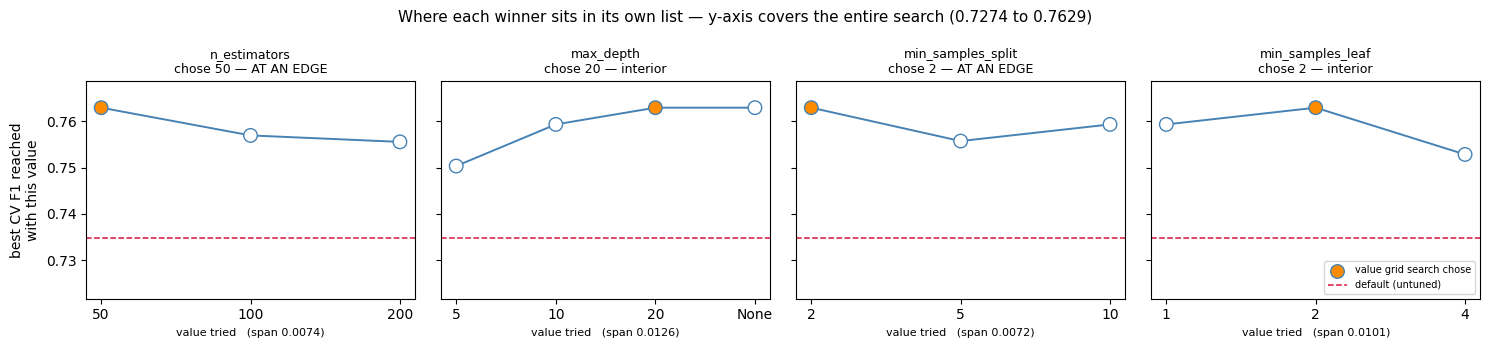

Boundary check — one row per hyperparameter
hyperparameter      list offered                 chose    position      span
n_estimators        [50, 100, 200]                  50        EDGE    0.0074
max_depth           [5, 10, 20, None]               20    interior    0.0126
min_samples_split   [2, 5, 10]                       2        EDGE    0.0072
min_samples_leaf    [1, 2, 4]                        2    interior    0.0101

2 of 4 winners sit at an END of the list they were given.
For those, the honest sentence is 'the search reached the edge of my grid',
not 'this value is best' — widen the list and re-run, unless the edge is a
hard limit of the parameter itself (min_samples_split cannot go below 2).

Widest effect of any single hyperparameter: 'max_depth' at 0.0126 F1 — against a
total spread of 0.0355 across all 108 configurations. Only a few knobs move the score at all,
which is the whole argument for random search (Bergstra & Bengio, 2012).


In [9]:
# WHERE DID EACH WINNER LAND IN ITS OWN LIST? — the boundary check.
# WHAT: one panel per hyperparameter. Each point is the BEST cross-validated F1 that
# any configuration containing that value reached (the maximum over every setting of
# the other three). The orange point is the value grid search finally chose.
# WHY the maximum and not the mean: the question is "could this value ever win",
# and the best case is exactly what answers it.
# WHY the y-axis is narrow here: it spans the whole search, and this figure asks
# WHERE the winner is, not HOW BIG the gap is — the true-scale bar chart earlier in
# the notebook is where that second question was settled. Both are needed.
# COST: zero new model fits — every number is already inside grid_search.cv_results_.
results = pd.DataFrame(grid_search.cv_results_)
param_names = list(param_grid.keys())

lo = min(float(results["mean_test_score"].min()), float(baseline_cv_f1))
hi = float(results["mean_test_score"].max())
pad = (hi - lo) * 0.16

fig, axes = plt.subplots(1, len(param_names), figsize=(15, 3.5), sharey=True)
summary = []
for ax, pname in zip(axes, param_names):
    values = param_grid[pname]
    labels = [str(v) for v in values]
    # str() on both sides so that None (a legal max_depth) compares cleanly
    col = results[f"param_{pname}"].astype(str)
    best_at = [float(results.loc[col == str(v), "mean_test_score"].max()) for v in values]
    winner = grid_search.best_params_[pname]
    at_edge = str(winner) in (str(values[0]), str(values[-1]))
    span = max(best_at) - min(best_at)
    summary.append((pname, winner, at_edge, span))

    ax.plot(labels, best_at, color="steelblue", lw=1.4, zorder=1)
    ax.scatter(labels, best_at, s=95, zorder=2, edgecolor="steelblue",
               c=["darkorange" if str(v) == str(winner) else "white" for v in values])
    # the untuned default: the line any value has to clear to be worth choosing
    ax.axhline(baseline_cv_f1, color="crimson", ls="--", lw=1.1)
    ax.set_title(f"{pname}\nchose {winner} — {'AT AN EDGE' if at_edge else 'interior'}",
                 fontsize=9)
    ax.set_xlabel(f"value tried   (span {span:.4f})", fontsize=8)
    ax.set_ylim(lo - pad, hi + pad)

axes[0].set_ylabel("best CV F1 reached\nwith this value")
axes[-1].scatter([], [], s=95, c="darkorange", edgecolor="steelblue",
                 label="value grid search chose")
axes[-1].plot([], [], color="crimson", ls="--", lw=1.1, label="default (untuned)")
axes[-1].legend(fontsize=7, loc="lower right")
fig.suptitle("Where each winner sits in its own list — y-axis covers the entire search "
             f"({results['mean_test_score'].min():.4f} to {hi:.4f})", fontsize=11)
plt.tight_layout()
plt.show()

# The picture as a table, so it can be checked rather than trusted.
print("=" * 78)
print("Boundary check — one row per hyperparameter")
print("=" * 78)
print(f"{'hyperparameter':<20}{'list offered':<26}{'chose':>8}{'position':>12}{'span':>10}")
for pname, winner, at_edge, span in summary:
    offered = "[" + ", ".join(str(v) for v in param_grid[pname]) + "]"
    print(f"{pname:<20}{offered:<26}{str(winner):>8}"
          f"{('EDGE' if at_edge else 'interior'):>12}{span:>10.4f}")

n_edge = sum(1 for _, _, e, _ in summary if e)
widest = max(summary, key=lambda r: r[3])
print(f"\n{n_edge} of {len(summary)} winners sit at an END of the list they were given.")
if n_edge:
    print("For those, the honest sentence is 'the search reached the edge of my grid',")
    print("not 'this value is best' — widen the list and re-run, unless the edge is a")
    print("hard limit of the parameter itself (min_samples_split cannot go below 2).")
print(f"\nWidest effect of any single hyperparameter: '{widest[0]}' at {widest[3]:.4f} F1 — "
      f"against a\ntotal spread of {hi - float(results['mean_test_score'].min()):.4f} "
      "across all "
      f"{len(results)} configurations. Only a few knobs move the score at all,")
print("which is the whole argument for random search (Bergstra & Bengio, 2012).")

### Reading the four panels

The red dashed line in every panel is the untuned default (0.7347). Every point in
all four panels sits above it, so no value in this grid was actively bad — the
question is only which end of each list the search drifted towards.

**First, an admission about the y-axis.** It is zoomed: it spans 0.7274 to 0.7629,
the whole search and nothing more, which is precisely the magnification the
true-scale bar chart earlier in this notebook warned you about. It is justified
here for one reason — that figure asked *how big* the gap is, and this one asks
*where* the winner sits, which is a question about position and needs magnification
to answer. Both figures are true; only one of them is allowed to appear alone. If
you show these four panels in your defence, show the true-scale chart beside them,
or you will have implied a difference of 0.013 is worth something.

- **`n_estimators` — the winner is at an edge.** 50 trees reached **0.7629**, 100
  reached 0.7569, 200 reached 0.7555. The line falls from left to right, and the
  orange point is on the leftmost value the list contained. The search was still
  improving in that direction when it ran out of list: the honest next step is to add
  10 and 25 trees and re-run, not to write "50 is optimal". (Note what this also
  means — the *cheapest* model in the grid won.)
- **`max_depth` — interior, but flat, not a peak.** 5 → 0.7503, 10 → 0.7593, then 20
  and `None` **both** reach 0.7629. The last two points are level because at this
  sample size a depth-20 tree and an unlimited tree are frequently the same tree. The
  choice of 20 over `None` was a tie broken by enumeration order, so do not report it
  as a finding.
- **`min_samples_split` — at an edge that cannot be widened.** The winner is 2, the
  leftmost value, which is also the smallest split size scikit-learn permits. This is a
  hard floor, not a grid that was drawn too narrow, and the correct report is *"the
  least-regularised setting won"*.
- **`min_samples_leaf` — the only genuine peak.** 1 → 0.7593, 2 → **0.7629**, 4 →
  0.7528. The line rises then falls, so 2 is a real interior optimum and this is the
  one value in the whole search you could defend as chosen rather than cornered.

**And look at the four spans printed under the panels: 0.0074, 0.0126, 0.0072, 0.0101.**
No single hyperparameter moved the best achievable score by more than about 0.013,
inside a total spread of 0.0355 across all 108 configurations. That is Bergstra and
Bengio's observation in one picture: a couple of knobs matter slightly, the rest barely
at all — which is exactly why sampling the space finds the good region about as fast as
enumerating it.

**The habit:** run this check on **every** list before you report a tuned model. It
costs no fits, and it is the difference between "the best depth is 20" and "the best
depth in the four values I happened to type is 20".

## 💬 Discuss

Three questions with no single right answer. Argue from the numbers this notebook printed.

1. **Which number goes on your results slide?** This run produced three true headlines: *"tuning improved cross-validated F1 by 0.0282"*; *"tuning reduced validation accuracy by 0.0112"*; and *"a random forest with default settings beats the majority-class baseline by nineteen points"* (0.8045 against 0.6145). All three are honest. Which do you show, and what does your choice say about what you believe the project is for? What would an examiner accuse you of if you showed only the first?
2. **When do you stop?** You have 640 fits behind you and a model that is not better than the default. Argue for exactly one of: widen the search space; change the model family; go and build new features; declare the default final and spend the remaining days on evaluation. Ground the argument in something printed above — the nine feature names, the 0.6145 majority baseline, the ~0.80 ceiling — not in a preference.
3. **Would you pay for this?** Netflix decided that several hundred models' worth of extra accuracy was not worth the engineering. Put a price on yours: if every 0.01 of F1 cost one extra day of the project, how many days is your current gain worth? Then answer the version a client asks instead: **what does 0.01 of F1 actually do for the person using the system?** If you cannot answer that second question, what does it tell you about the metric you chose?

## ⚠️ Where this breaks

Hyperparameter search has the widest gap in this course between how productive it feels and how much it usually earns. Here is where it stops paying.

- **A search can only find what you put in the grid.** The boundary-check figure above tested all four lists, and **two of the four winners sit at an end of theirs**. `max_depth` chose 20 out of `[5, 10, 20, None]` — interior, and tied with `None`, so that list was wide enough. But `n_estimators` chose **50**, the fewest trees offered, and `min_samples_split` chose **2**, the smallest split size that exists. When a winner sits at an edge, the honest conclusion is *"the search reached the boundary of my grid"*, not *"50 is best"*: widen the list (add 10 and 25 trees) and re-run — unless the edge is a hard limit of the parameter, as `min_samples_split=2` is. Check where the winner sits in **every** list before you report it.
- **Tuning cannot repair a feature set.** Both searches flatten out near 0.80 accuracy because that is roughly what these nine columns support — whether a 1912 passenger survived was never a clean function of class, sex, age, fare and family size. **The assumption that has to hold before tuning is worth doing: the features already carry the signal, and only the model's flexibility is holding you back.** When that is false, one hour spent building a new feature beats a day of grid search every time.
- **Tuning against a small validation set mostly measures the validation set.** With 179 rows, one flipped prediction is 0.56% of accuracy. That is why the tuned model came out 0.0112 *below* the baseline on validation while sitting 0.0282 *above* it on cross-validated F1: the two disagree because one of them is barely distinguishable from noise. Choose with cross-validation, keep the held-out set for one final measurement, and do not re-tune after looking at it — every extra look converts a held-out set a little further into a training set.
- **`scoring='f1'` was a decision, and every result above inherits it.** Set the scorer to `recall` and the search returns different winners, because it is optimising a different definition of good. Pick the metric from the harm you are trying to avoid, in the proposal, *before* the search — otherwise you will end up picking the metric that flatters the model you already have.
- **One random seed is one sample.** Every number here came from `random_state=42`. Re-run with three other seeds before claiming any difference under roughly two points is real. Reporting a single seed as though it were a result is the most common statistical error in student capstones.
- **When NOT to tune at all.** If your model has not yet beaten a baseline someone could compute *without* machine learning, tuning is the wrong tool: you have a framing problem or a feature problem, not a hyperparameter problem. And when the defaults already sit near the ceiling — as they do here — the professional move is to write *"the tuned model was within noise of the defaults, so the defaults were kept"* and spend the days on evaluation, failure analysis and the demo. Those are worth 35 of the 100 points in this course. Hyperparameters are worth none of them directly.

## Summary

### Key Concepts:
1. **Baseline Model**: Establish performance benchmark with default parameters
2. **Grid Search**: Exhaustive search over all parameter combinations (computationally expensive)
3. **Random Search**: Sample random combinations (more efficient for large spaces)
4. **Cross-Validation**: Use CV scores for hyperparameter selection, not validation set
5. **Honest reporting**: judge a search on the criterion it optimized; a strong default baseline is a legitimate final choice

### What happened in this run (real Titanic manifest):
Grid search raised the cross-validated F1 it was optimizing from 0.7347 to 0.7629 (+0.0282), yet the tuned model's accuracy on the held-out 179 passengers came out at 0.7933 against the baseline's 0.8045 (−0.0112). Random search, sampling only 20 of a wider space, landed at CV F1 0.7555 — within 0.0074 of the exhaustive grid, for a fifth of the fits. Both searches comfortably beat the 0.6145 majority-class baseline, and neither pushed past roughly 0.80, which is about as far as these nine columns can carry a model. The "Reading the result honestly" section above shows how to interpret that.

### Best Practices:
- Always establish baseline first
- Use cross-validation for hyperparameter tuning
- Keep validation set separate for final evaluation
- Document all hyperparameter configurations tried
- Track training time vs performance trade-offs

### Running this on your own project data
Save your dataset as `data/my_project_data.csv`, set `TARGET` in the loading cell to your label
column, and re-run. Everything below adapts — including the computed verdict on whether tuning helped.

**Reference:** Course 12, Unit 3: "Implementation and Development of the Project Idea" — training and tuning activities demonstrated above; see notebook 01 of this unit for the data collection and preprocessing pipeline.


## 🔭 State of the field (2026)

**What practitioners do now.** On tabular data of this size, the first move after the default baseline is no longer a hyperparameter search — it is a *second baseline* drawn from a tabular foundation model. These are pretrained networks used in-context: you fit nothing per dataset, so the extra baseline costs minutes rather than the 640 fits this notebook just spent. Their authors report that TabPFN-2.5 substantially outperforms tuned tree-based models and matches AutoGluon 1.4, "a complex four-hour tuned ensemble", and that TabPFN-3 carries the same approach to datasets of 1M training rows while running up to 20× faster than TabPFN-2.5. Those are the authors' own comparisons, so treat such a model exactly as this notebook treats a tuned one: measure it on your own held-out split, across more than one seed, before you believe it. If your project adapts a large language model rather than a tabular one, the equivalent ladder is context first (prompting and retrieval), then a low-rank adapter — LoRA reports 10,000× fewer trainable parameters than full fine-tuning of GPT-3 175B at on-par quality — and only then full fine-tuning; reaching for fine-tuning first is the most common wrong answer in a capstone.

**Why this lesson is still exactly what to learn.** Every one of those options is *another candidate entered into the same comparison* — and the comparison is the mechanism this notebook teaches. Baseline → search → read the result on the criterion it optimised → decide whether the gain was worth its cost is unchanged; only the list of candidates got longer, which makes the "was it worth it?" question above harder and more valuable, not obsolete. Grid search and random search remain the tuning methods AIAT 126 examines and the ones your gate-3 evidence has to show you ran and interpreted. The one thing worth adding to your own project: before spending a week on hyperparameters, run one foundation-model baseline, write the number down, and report it honestly if it wins.

*Sources: Grinsztajn et al. (2025), TabPFN-2.5, [arXiv:2511.08667](https://arxiv.org/abs/2511.08667) · Grinsztajn et al. (2026), TabPFN-3, [arXiv:2605.13986](https://arxiv.org/abs/2605.13986) · Hu et al. (2021), LoRA, [arXiv:2106.09685](https://arxiv.org/abs/2106.09685) — full entries 8–10 in the References below.*

## 📚 References

1. Breiman, L. (2001). *Random Forests*. Machine Learning, 45(1), 5–32.
2. Bergstra, J., & Bengio, Y. (2012). *Random Search for Hyper-Parameter Optimization*. Journal of Machine Learning Research, 13, 281–305. <https://jmlr.org/papers/v13/bergstra12a.html>
3. Snoek, J., Larochelle, H., & Adams, R. P. (2012). *Practical Bayesian Optimization of Machine Learning Algorithms*. NeurIPS 2012. <https://arxiv.org/abs/1206.2944>
4. Bischl, B., Binder, M., Lang, M., et al. (2021). *Hyperparameter Optimization: Foundations, Algorithms, Best Practices and Open Challenges*. arXiv. <https://arxiv.org/abs/2107.05847>

**Cases cited in this lesson**

5. Ferrari Dacrema, M., Cremonesi, P., & Jannach, D. (2019). *Are We Really Making Much Progress? A Worrying Analysis of Recent Neural Recommendation Approaches*. **RecSys 2019.** <https://arxiv.org/abs/1907.06902> — 18 neural methods, 7 reproducible, 6 of those beaten by well-tuned simple baselines.
6. Melis, G., Dyer, C., & Blunsom, P. (2018). *On the State of the Art of Evaluation in Neural Language Models*. **ICLR 2018.** <https://arxiv.org/abs/1707.05589> — a properly regularised, heavily tuned standard LSTM outperforming the architectures published after it.
7. Amatriain, X., & Basilico, J. (2012). *Netflix Recommendations: Beyond the 5 Stars (Part 1)*. Netflix Technology Blog — the statement that the Netflix Prize winning ensemble was not deployed because the measured accuracy gains "did not seem to justify the engineering effort needed to bring them into a production environment."

**Recent work (2025–2026)**

8. Grinsztajn, L., et al. (2025). *TabPFN-2.5: Advancing the State of the Art in Tabular Foundation Models*. arXiv:2511.08667. <https://arxiv.org/abs/2511.08667> — a pretrained tabular model used in-context; the authors report that it substantially outperforms tuned tree-based models and matches the accuracy of AutoGluon 1.4, "a complex four-hour tuned ensemble".
9. Grinsztajn, L., Flöge, K., Key, O., et al. (2026). *TabPFN-3: Technical Report*. arXiv:2605.13986. <https://arxiv.org/abs/2605.13986> — carries the same in-context approach to datasets with 1M training rows, reported up to 20× faster than TabPFN-2.5.
10. Hu, E. J., Shen, Y., Wallis, P., Allen-Zhu, Z., Li, Y., Wang, S., Wang, L., & Chen, W. (2021). *LoRA: Low-Rank Adaptation of Large Language Models*. arXiv:2106.09685. <https://arxiv.org/abs/2106.09685> — the adapter method behind "adapt a large model without retraining it": reported 10,000× fewer trainable parameters than fine-tuning GPT-3 175B with Adam, at on-par quality.